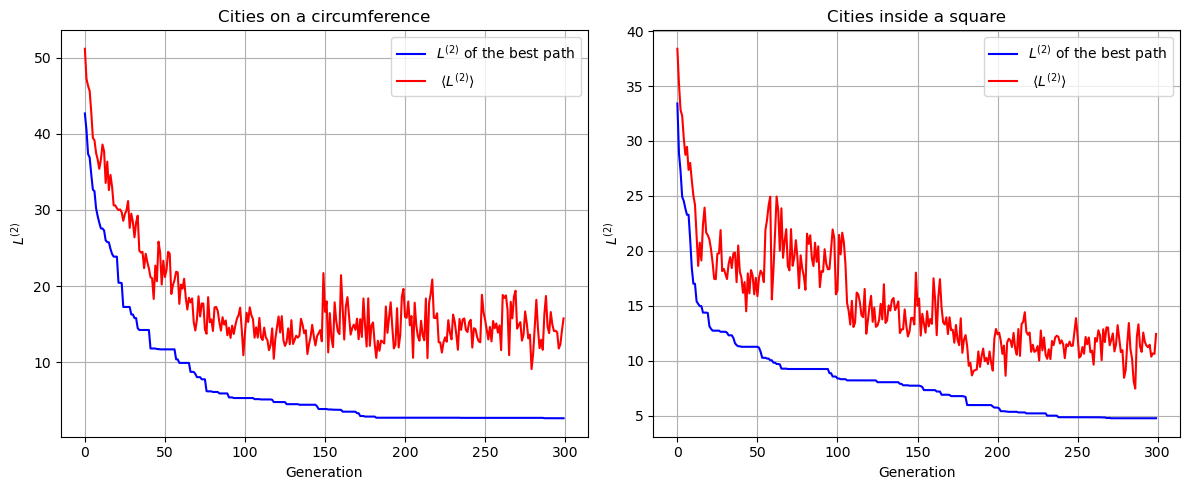

In [9]:
import matplotlib.pyplot as plt
import numpy as np

generation_c, L2_c, L2_mean_c = np.loadtxt("./simulazioni-eseguite/circumference/results.dat", unpack=True, usecols=(0,1,2), dtype=str)
generation_s, L2_s, L2_mean_s = np.loadtxt("./simulazioni-eseguite/square/results.dat", unpack=True, usecols=(0,1,2), dtype=str)
generation_c = generation_c.astype(int)
generation_s = generation_s.astype(int)
L2_c = L2_c.astype(float)
L2_s = L2_s.astype(float)
L2_mean_c = L2_mean_c.astype(float)
L2_mean_s = L2_mean_s.astype(float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

ax1.plot(generation_c, L2_c, label=r"$L^{(2)}$ of the best path", color='blue')
ax1.plot(generation_c, L2_mean_c, label=r" $\langle L^{(2)}\rangle$", color='red')
ax1.set_title("Cities on a circumference")
ax1.set_xlabel('Generation')
ax1.set_ylabel(r"$L^{(2)}$")
ax1.grid(True)
ax1.legend()

#nel secondo grafico plotterò città quadrate
ax2.plot(generation_s, L2_s, label=r"$L^{(2)}$ of the best path", color='blue')
ax2.plot(generation_s, L2_mean_s, label=r" $\langle L^{(2)}\rangle$", color='red')
ax2.set_title("Cities inside a square")
ax2.set_xlabel('Generation')
ax2.set_ylabel(r"$L^{(2)}$")
ax2.grid(True)
ax2.legend()

# Margini stretti e layout ordinato
plt.tight_layout()
plt.show()


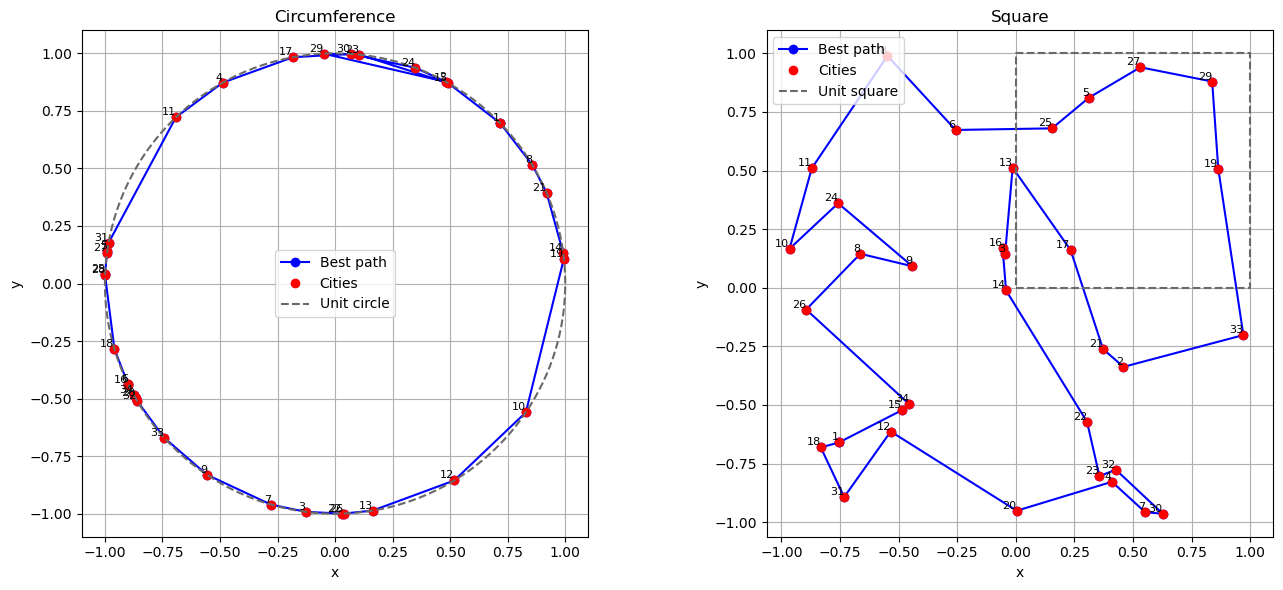

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def load_and_plot(ax, cities_file, route_file, title):
    name_cities, x, y = np.loadtxt(cities_file, unpack=True, usecols=(0,1,2), dtype=str)
    x = x.astype(float)
    y = y.astype(float)

    best_route = np.loadtxt(route_file, dtype=str)
    n_cities = len(best_route)
    best_route_coord = np.zeros((2, n_cities + 1))  # +1 per chiudere il percorso

    for i in range(n_cities):
        city_name = best_route[i]
        index = np.where(name_cities == city_name)[0][0]
        best_route_coord[0, i] = x[index]
        best_route_coord[1, i] = y[index]

    # Chiudi il percorso collegando l'ultimo punto al primo
    best_route_coord[:, -1] = best_route_coord[:, 0]

    ax.plot(best_route_coord[0], best_route_coord[1], 'o-', label='Best path', color='blue')
    ax.plot(x, y, 'o', label='Cities', color='red')

    for i in range(len(name_cities)):
        ax.text(x[i], y[i], name_cities[i], fontsize=8, ha='right', va='bottom')

    if "circumference" in cities_file:
        theta = np.linspace(0, 2*np.pi, 300)
        ax.plot(np.cos(theta), np.sin(theta), color='dimgray', linestyle='--', label='Unit circle')
    elif "square" in cities_file:
        square_x = [0, 1, 1, 0, 0]
        square_y = [0, 0, 1, 1, 0]
        ax.plot(square_x, square_y, color='dimgray', linestyle='--', label='Unit square')

    ax.set_aspect('equal')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

load_and_plot(ax1,"./simulazioni-eseguite/circumference/cities.dat","./simulazioni-eseguite/circumference/best_route.dat","Circumference")
load_and_plot(ax2,"./simulazioni-eseguite/square/cities.dat","./simulazioni-eseguite/square/best_route.dat","Square")

plt.tight_layout()
plt.show()
